cargamos los datos y entrenamos el modelo

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3187 - loss: 1.9421 - val_accuracy: 0.7119 - val_loss: 0.9472
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7523 - loss: 0.8141 - val_accuracy: 0.8534 - val_loss: 0.4943
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8614 - loss: 0.4457 - val_accuracy: 0.9032 - val_loss: 0.3143
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9093 - loss: 0.3007 - val_accuracy: 0.9311 - val_loss: 0.2255
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9397 - loss: 0.2042 - val_accuracy: 0.9350 - val_loss: 0.2113
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.95      0.97      0.96      1135
           2       0.89      0.97      0.93      1032
           3       0.92      0.92      0.92      1010
           4       0.97      0.91      0.94     

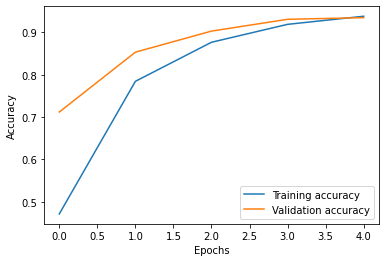

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from TheModel import build

# Cargar datos
local_data = np.load("local_data_splits\\local_data_split_2.npz")
x_local, y_local = local_data["x"], local_data["y"]

datos_test = np.load("local_data_splits\\datos_test_mnist.npz")
x_test, y_test = datos_test["x_test"], datos_test["y_test"]

# Construir y compilar el modelo
local_model = build.build_it()

# Entrenar y validar
history = local_model.fit(x_local, y_local, epochs=5, validation_data=(x_test, y_test))

# Evaluar y reportar resultados
y_pred = local_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

# Gráfica de precisión
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Guardar modelo entrenado
local_model.save("modelos/lmodel_2.keras")
